# Plant transfer function 
Here is plotted the tranfer function of the plant we need to control

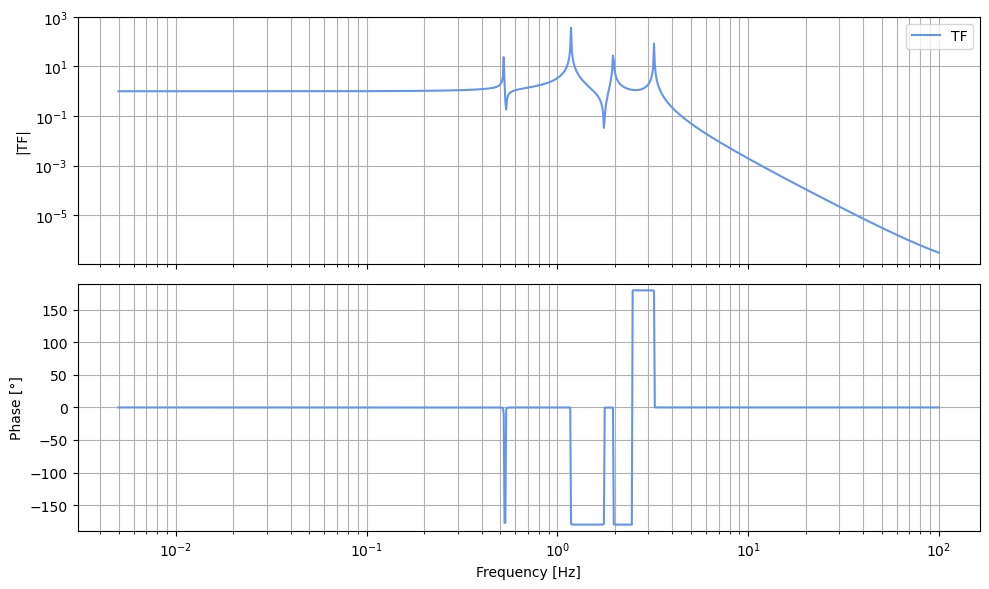

In [257]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# ===== CARICAMENTO DATI =====
data = pd.read_csv('ZtoZ.csv', header=None)
f = data[0].values
mag = data[1].values
phase = data[2].values  # in radianti

# ===== PLOT =====
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.loglog(f, mag, label='TF', color='cornflowerblue')
ax2.semilogx(f, np.degrees(phase), color='cornflowerblue')
ax2.set_ylim(-190, 190)

ax1.set_ylabel('|TF|')
ax2.set_ylabel('Phase [°]')
ax2.set_xlabel('Frequency [Hz]')
ax1.grid(True, which='both')
ax2.grid(True, which='both')
ax1.legend()
plt.tight_layout()
plt.show()


# Pid implementation
Here we implement the pure PID controller defined as $PID = K_p + K_{d}s + K_{i}/s  $ with $s = i\omega$. \
**$K_p$:** modulates the gain of the controller, increaing K_p shifts right unity gain frequencies (UGFs).\
**$K_d$:** compensates phase loss at UGFs, increasing phase margin (PM) and then damping resonances. \
**$K_i$:** increases phase loss, useful only if you want to drive the plant to a certain setpoint. \
The Open Loop (OL) transfer function is calculated as $OL = TF * PID$. 
### Main rules:
1) The first UGF defines the bandwidth of your controller $f_{BW}$ as its frequency and the reactivity, described by the rise time $t_r \approx 0.35/f_{BW}$. 
2) The phase margin $PM = 180* - |\text{phase}(OL(UGF))|$ has to be at least $45°$.
### Procedure:
1) Set $K_d = K_i = 0$ and start with a small $K_p$, increasing $K_p$ until the first UGF as a good PM. 
2) Add $K_d$: gain phase margin and damp oscillations.
3) If you nedd to drive to a certain set point, add $K_i$ after having granted stability eith $K_p$ and $K_d$.



--- UGF Information ---
First UGF:
  Frequency  = 1.739 Hz
  Phase margin = 55.91°
  Response time = 201.31 ms

Other UGFs:
  Frequency = 1.773 Hz,  Phase margin = 124.47°
  Frequency = 5.148 Hz,  Phase margin = 102.95°


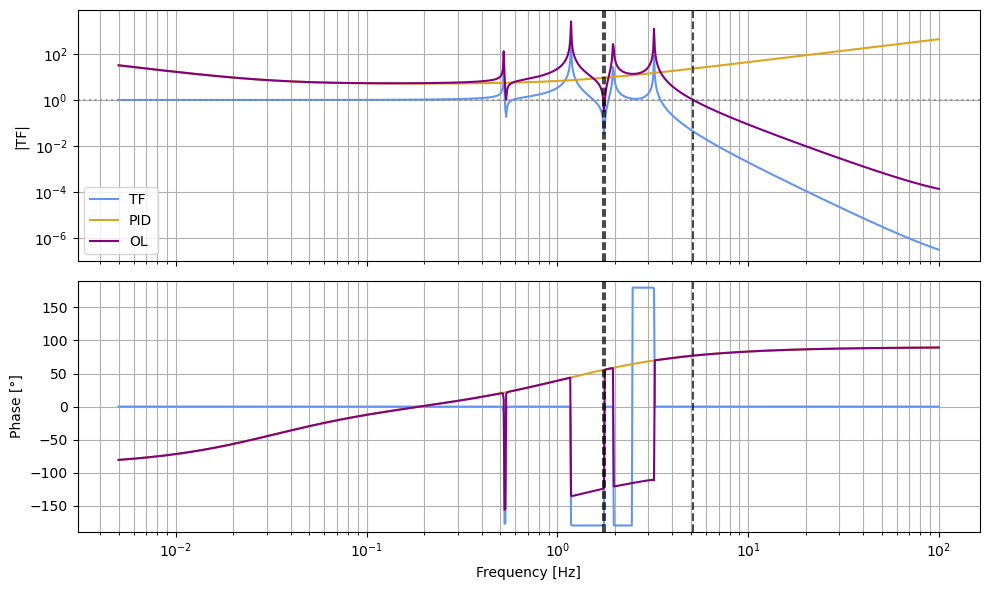

In [258]:
from scipy.interpolate import interp1d

omega = 2 * np.pi * f
s = 1j * omega

# ===== PID PARAMS =====
Kp, Kd, Ki = 5.2, 0.7, 1.0

# ===== PID =====
PID_complex = (Kp + Kd * s + Ki / s)

# ===== TF  =====
TF_complex = mag * np.exp(1j * phase)
OL_complex = TF_complex * PID_complex
mag_OL = np.abs(OL_complex)
phase_OL_deg = np.degrees(np.angle(OL_complex))

# ===== Find ALL UGFs (|OL| = 1) =====
crossings = np.where(np.diff(np.sign(mag_OL - 1)))[0]
ugf_freqs = []
PMs = []
Trs = []

for i in crossings:
    # Interpolate to find exact UGF frequency
    f1, f2 = f[i], f[i+1]
    m1, m2 = mag_OL[i], mag_OL[i+1]
    ugf = float(interp1d([m1, m2], [f1, f2])(1))
    ugf_freqs.append(ugf)

    # Interpolate to get phase at UGF
    ph1, ph2 = phase_OL_deg[i], phase_OL_deg[i+1]
    phase_at_ugf = float(interp1d([f1, f2], [ph1, ph2])(ugf))
    pm = 180 - abs(phase_at_ugf)
    PMs.append(pm)

    # Response time
    Trs.append(0.35 / ugf)

# ===== Print UGF info to terminal =====
if ugf_freqs:
    print(f"--- UGF Information ---")
    print(f"First UGF:")
    print(f"  Frequency  = {ugf_freqs[0]:.3f} Hz")
    print(f"  Phase margin = {PMs[0]:.2f}°")
    print(f"  Response time = {Trs[0]*1e3:.2f} ms\n")

    if len(ugf_freqs) > 1:
        print("Other UGFs:")
        for i in range(1, len(ugf_freqs)):
            print(f"  Frequency = {ugf_freqs[i]:.3f} Hz,  Phase margin = {PMs[i]:.2f}°")
else:
    print("No unity-gain frequency (UGF) found.")

# ===== Plot =====
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.loglog(f, mag, label='TF', color='cornflowerblue')
ax1.loglog(f, np.abs(PID_complex), label='PID', color='goldenrod')
ax1.loglog(f, mag_OL, label='OL', color='purple')
ax1.axhline(1, color='gray', linestyle=':', alpha=0.7)

ax2.semilogx(f, np.degrees(phase), color='cornflowerblue')
ax2.semilogx(f, np.degrees(np.angle(PID_complex)), color='goldenrod')
ax2.semilogx(f, phase_OL_deg, color='purple')

# ===== UGF vertical lines only =====
for ugf in ugf_freqs:
    ax1.axvline(ugf, color='black', linestyle='--', alpha=0.7)
    ax2.axvline(ugf, color='black', linestyle='--', alpha=0.7)

# ===== Labels =====
ax1.set_ylabel('|TF|')
ax2.set_ylabel('Phase [°]')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylim(-190, 190)
ax1.grid(True, which='both')
ax2.grid(True, which='both')
ax1.legend()
plt.tight_layout()
plt.show()


# Closed loop 
The Closed loop (CL) transfer function is calculated as $ CL = OL/(1+OL) $, this is the transfer function measured when the control is closed.

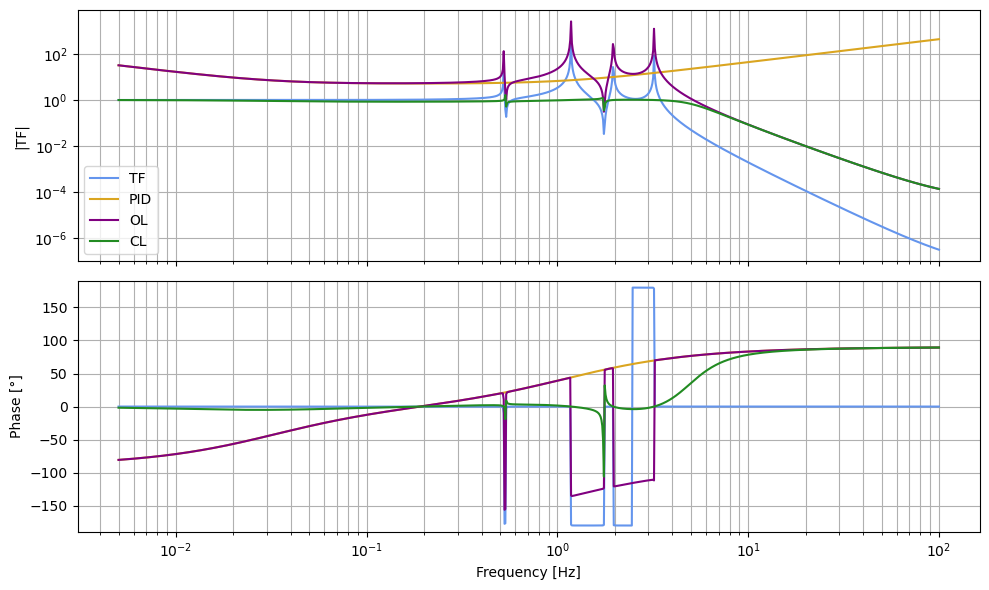

In [259]:
# ===== Closed loop =====
CL_complex = OL_complex / (1 + OL_complex)
mag_CL = np.abs(CL_complex)
phase_CL_deg = np.degrees(np.angle(CL_complex))

# ===== PLOT =====
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.loglog(f, mag, label='TF', color='cornflowerblue')
ax1.loglog(f, np.abs(PID_complex), label='PID', color='goldenrod')
ax1.loglog(f, mag_OL, label='OL', color='purple')
ax1.loglog(f, mag_CL, label='CL', color='forestgreen')


ax2.semilogx(f, np.degrees(phase), color='cornflowerblue')
ax2.semilogx(f, np.degrees(np.angle(PID_complex)), color='goldenrod')
ax2.semilogx(f, phase_OL_deg, color='purple')
ax2.semilogx(f, phase_CL_deg, color='forestgreen')

ax1.set_ylabel('|TF|')
ax2.set_ylabel('Phase [°]')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylim(-190, 190)
ax1.grid(True, which='both')
ax2.grid(True, which='both')
ax1.legend()
plt.tight_layout()
plt.show()


# Filter implementation
Here we implement the roll off filter to limit the derivative gain at high frequencies. 

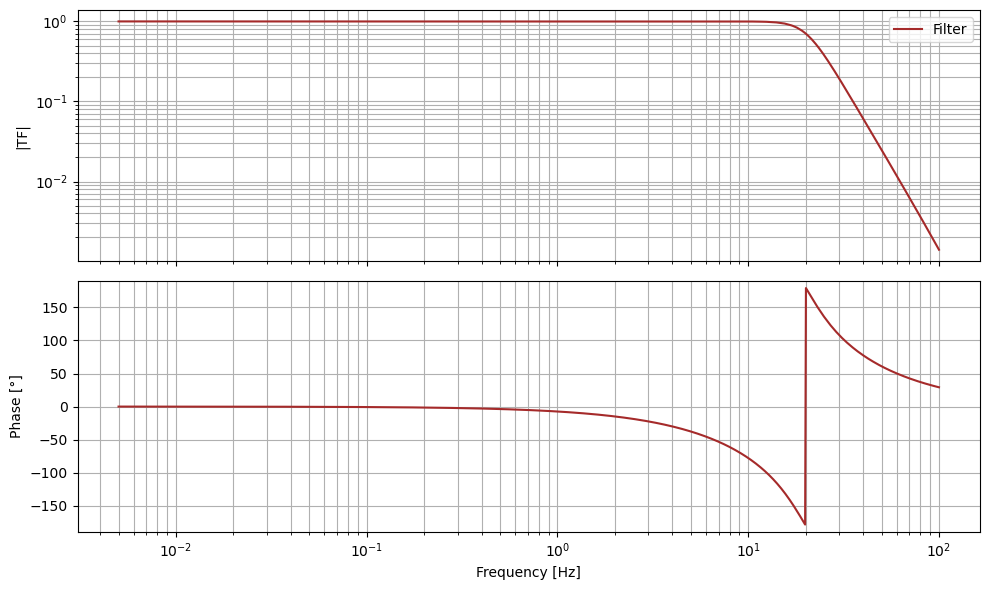

In [260]:
from scipy.signal import butter, freqz


f_cutoff = 20  
fs = 1000  
order = 4  

#since digital filter work with normalized frequencies (where 1 = fs) we have tu normalize it
f_cutoff_norm = f_cutoff / (fs / 2)

# b are numerator coefficients, a are denominator coefficients
b, a = butter(order, f_cutoff_norm, btype='low', analog=False)

#here we evaluete the fequency response of the filter (f_filter is an array of frequencies,  )
f_filter, h = freqz(b, a, worN=len(f), fs=fs)

#here we interpolate h with the f array of frequencies of previous plots since f_filter may differ from it
H_interp = interp1d(f_filter, h, kind='linear', bounds_error=False, fill_value="extrapolate")
h_f = H_interp(f)

mag_filter = np.abs(h_f)
phase_filter = np.degrees(np.angle(h_f))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.loglog(f, mag_filter, label='Filter', color='brown')
ax2.semilogx(f, phase_filter, color='brown')

ax1.set_ylabel('|TF|')
ax2.set_ylabel('Phase [°]')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylim(-190, 190)
ax1.grid(True, which='both')
ax2.grid(True, which='both')
ax1.legend()
plt.tight_layout()
plt.show()


# Final plot
Here we plot the final CL transfer function, obtained using the filtered open loop $OL_{filtered} = TF*PID*F$

--- UGFs after filtering ---
First UGF (Filtered):
  Frequency  = 1.739 Hz
  Phase margin = 42.89°
  Response time = 201.32 ms

UGF 2 (Filtered):
  Frequency  = 1.773 Hz
  Phase margin = 137.73°
UGF 3 (Filtered):
  Frequency  = 5.147 Hz
  Phase margin = 141.80°


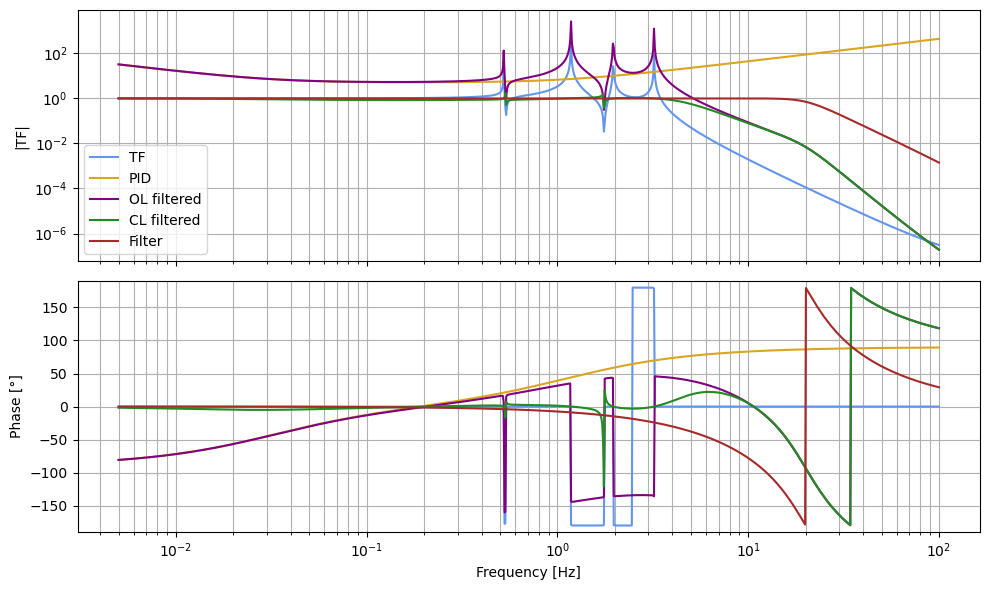

In [261]:
from scipy.interpolate import interp1d

# ===== Open loop filtrata =====
OL_filt = OL_complex * h_f
CL_filt = OL_filt / (1 + OL_filt)

mag_OL_filt = np.abs(OL_filt)
phase_OL_filt = np.degrees(np.angle(OL_filt))
mag_CL_filt = np.abs(CL_filt)
phase_CL_filt = np.degrees(np.angle(CL_filt))

# ===== Trova TUTTE le nuove UGF (|OL_filt| = 1) =====
crossings_filt = np.where(np.diff(np.sign(mag_OL_filt - 1)))[0]
ugf_freqs_filt = []
PMs_filt = []
Trs_filt = []

for i in crossings_filt:
    f1, f2 = f[i], f[i+1]
    m1, m2 = mag_OL_filt[i], mag_OL_filt[i+1]
    ugf = float(interp1d([m1, m2], [f1, f2])(1))
    ugf_freqs_filt.append(ugf)

    # Interpolazione per fase
    ph1, ph2 = phase_OL_filt[i], phase_OL_filt[i+1]
    phase_at_ugf = float(interp1d([f1, f2], [ph1, ph2])(ugf))
    pm = 180 - abs(wrap_phase_deg(phase_at_ugf))
    PMs_filt.append(pm)
    Trs_filt.append(0.35 / ugf)

# ===== Stampa info UGF filtrate =====
if ugf_freqs_filt:
    print(f"--- UGFs after filtering ---")
    for i, (ugf, pm, Tr) in enumerate(zip(ugf_freqs_filt, PMs_filt, Trs_filt)):
        label = "First UGF (Filtered):" if i == 0 else f"UGF {i+1} (Filtered):"
        print(f"{label}")
        print(f"  Frequency  = {ugf:.3f} Hz")
        print(f"  Phase margin = {pm:.2f}°")
        if i == 0:
            print(f"  Response time = {Tr*1e3:.2f} ms\n")
else:
    print("No new UGFs")

# ===== Plot =====
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)


# Magnitudine
ax1.loglog(f, mag, label='TF', color='cornflowerblue')
ax1.loglog(f, np.abs(PID_complex), label='PID', color='goldenrod')
ax1.loglog(f, mag_OL_filt, label='OL filtered', color='purple')
ax1.loglog(f, mag_CL_filt, label='CL filtered', color='forestgreen')
ax1.loglog(f, mag_filter, label='Filter', color='brown')
ax1.set_title('ZtoZ')

# Fase
ax2.semilogx(f, np.degrees(phase), color='cornflowerblue')
ax2.semilogx(f, np.degrees(np.angle(PID_complex)), color='goldenrod')
ax2.semilogx(f, phase_OL_filt, color='purple')
ax2.semilogx(f, phase_CL_filt, color='forestgreen')
ax2.semilogx(f, phase_filter, color='brown')

# # Linee verticali UGF filtrate
# for ugf in ugf_freqs_filt:
#     ax1.axvline(ugf, color='black', linestyle='--', alpha=0.7)
#     ax2.axvline(ugf, color='black', linestyle='--', alpha=0.7)

# Etichette
ax1.set_ylabel('|TF|')
ax2.set_ylabel('Phase [°]')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylim(-190, 190)
ax1.grid(True, which='both')
ax2.grid(True, which='both')
ax1.legend()
plt.tight_layout()
plt.show()
